In [ ]:
#tic-tac-toe
def print_board(board):
    """Prints the Tic-Tac-Toe board in a 3x3 format."""
    print("\nCurrent board:")
    print(f" {board[0]} | {board[1]} | {board[2]}")
    print("---+---+---")
    print(f" {board[3]} | {board[4]} | {board[5]}")
    print("---+---+---")
    print(f" {board[6]} | {board[7]} | {board[8]}")
    print()

def check_winner(board, player):
    """Checks if the given player has won."""
    # win conditions
    win_conditions = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # Rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # Columns
        [0, 4, 8], [2, 4, 6]              # Diagonals
    ]
    # check each win condition to see if it matches the player's symbol
    for condition in win_conditions:
        if board[condition[0]] == board[condition[1]] == board[condition[2]] == player:
            return True  # return early if win
    return False

def check_tie(board):
    """Checks if the game is a tie."""
    return " " not in board  # Returns True if there are no empty spots

def get_player_input(player, board):
    """Prompts the player to choose a position and validates it."""
    while True:
        try:
            position = input(f"Player {player}, choose a position (1-9): ").strip()
            if not position.isdigit():
                print("Please enter a valid number.")
                continue
            
            position = int(position) - 1
            if position < 0 or position > 8:
                print("Invalid position. Choose a number between 1 and 9.")
            elif board[position] != " ":
                print("Position already taken. Choose another spot.")
            else:
                return position  # Position is valid and empty
        except ValueError:
            print("Please enter a valid number.")  # input errors

def play_game():
    """Main game loop that controls the flow of the Tic-Tac-Toe game."""
    board = [" "] * 9
    current_player = "X"
    
    while True:
        print_board(board)
        position = get_player_input(current_player, board)
        board[position] = current_player  # Update board with the player's move
        
        # Check for a win or tie after each move
        if check_winner(board, current_player):
            print_board(board)
            print(f"Congratulations, Player {current_player} wins!")
            break
        elif check_tie(board):
            print_board(board)
            print("It's a tie!")
            break
        
        # Switch player after valid move
        current_player = "O" if current_player == "X" else "X"

    # Replay option
    replay = input("Play again? (y/n): ").strip().lower()
    if replay == "y":
        play_game()
    else:
        print("Thanks for playing! Come back soon!")

# Start the game
play_game()

In [ ]:
# List to store tasks
tasks = []

def add_task():
    task = input("Enter the task to add: ").strip()
    if task:
        tasks.append(task)
        print(f"Task '{task}' added.")
    else:
        print("Task cannot be empty.")

def view_tasks():
    if tasks:
        print("\nYour To-Do List:")
        for i, task in enumerate(tasks, start=1):
            print(f"{i}. {task}")
    else:
        print("\nYour To-Do list is empty.")

def delete_task():
    view_tasks()
    if tasks:
        try:
            index = int(input("Enter the number of the task to delete: ")) - 1
            if 0 <= index < len(tasks):
                removed_task = tasks.pop(index)
                print(f"Task '{removed_task}' deleted.")
            else:
                print("Invalid index. Please try again.")
        except ValueError:
            print("Please enter a valid number.")

def main():
    while True:
        print("\nOptions:")
        print("1. Add Task")
        print("2. View Tasks")
        print("3. Delete Task")
        print("4. Exit")
        
        choice = input("Choose an option (1-4): ").strip()
        
        if choice == "1":
            add_task()
        elif choice == "2":
            view_tasks()
        elif choice == "3":
            delete_task()
        elif choice == "4":
            print("Exiting the application. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 4.")

# Run the to-do list application
main()

Path found: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6)]


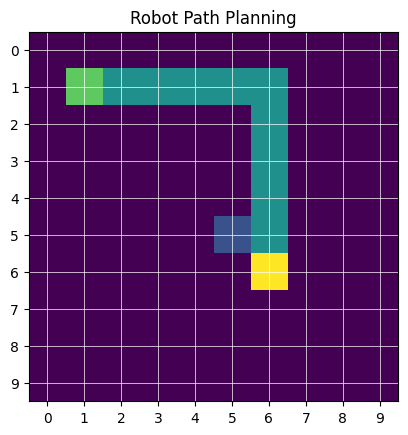

In [ ]:
#Pathfinding A* algorithm
import numpy as np
import matplotlib.pyplot as plt

class Node:
    def __init__(self, position, parent=None):
        self.position = position
        self.parent = parent
        self.g = 0  
        self.h = 0  
        self.f = 0  

def a_star(grid, start, end):
    open_list = []
    closed_list = set()

    start_node = Node(start)
    end_node = Node(end)
    open_list.append(start_node)
    
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)] 

    while open_list:
        open_list.sort(key=lambda node: node.f)
        current_node = open_list.pop(0)
        closed_list.add(current_node.position)

        if current_node.position == end_node.position:
            path = []
            while current_node:
                path.append(current_node.position)
                current_node = current_node.parent
            return path[::-1] 
        
        for direction in directions:
            new_position = (current_node.position[0] + direction[0],
                            current_node.position[1] + direction[1])
            if (0 <= new_position[0] < grid.shape[0] and
                0 <= new_position[1] < grid.shape[1] and
                grid[new_position[0]][new_position[1]] == 0):

                if new_position in closed_list:
                    continue
                neighbor = Node(new_position, current_node)
                neighbor.g = current_node.g + 1
                neighbor.h = abs(new_position[0] - end_node.position[0]) + abs(new_position[1] - end_node.position[1])
                neighbor.f = neighbor.g + neighbor.h
                if any(open_node.position == neighbor.position and neighbor.g > open_node.g for open_node in open_list):
                    continue

                open_list.append(neighbor)

    return None  

def visualize_path(grid, path, start, end):
    for position in path:
        grid[position[0]][position[1]] = 2

    grid[start[0]][start[1]] = 3
    grid[end[0]][end[1]] = 4

    
    plt.imshow(grid, cmap="viridis", interpolation="nearest")
    plt.title("Robot Path Planning")
    plt.xticks(np.arange(0, grid.shape[1], 1))
    plt.yticks(np.arange(0, grid.shape[0], 1))
    plt.grid(which='both', color='white', linestyle='-', linewidth=0.5)
    plt.show()

def main():
    rows = int(input("Enter the number of rows for the grid: "))
    cols = int(input("Enter the number of columns for the grid: "))
    grid = np.zeros((rows, cols), dtype=int)

    num_obstacles = int(input("Enter the number of obstacles: "))
    for _ in range(num_obstacles):
        x, y = map(int, input("Enter obstacle coordinates (row, col): ").split())
        grid[x][y] = 1

    start = tuple(map(int, input("Enter the starting point (row, col): ").split()))
    end = tuple(map(int, input("Enter the destination point (row, col): ").split()))

    path = a_star(grid, start, end)
    if path:
        print("Path found:", path)
        visualize_path(grid, path, start, end)
    else:
        print("No valid path found.")

if __name__ == "__main__":
    main()
